In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests
import json
import utils

#team_number = input("What team do you want information on? ")
#team_number = int(team_number)
#team_number = 578
#team_number = 27 # Team Rush
#team_number = 1559 # Devil Tech (Victor)
#team_number = 1519 # Greece Gladiators
#team_number = 3181 # Pittsford
#team_number = 20

measure = "Final" # Auto Teleop or Final
#utils.get_viz(utils.get_win_loss_data(team_number), team_number)

In [2]:
headers = {"X-TBA-Auth-Key": "uTHeEfPigDp9huQCpLNkWK7FBQIb01Qrzvt4MAjh9z2WQDkrsvNE77ch6bOPvPb6"}

def tba_teams(event_key: str):
    response = requests.get(
        f"https://www.thebluealliance.com/api/v3/event/{event_key}/teams", headers
    )
    with open(f"data/teams_{event_key}.json", "wb") as f:
        f.write(response.content)
    return()

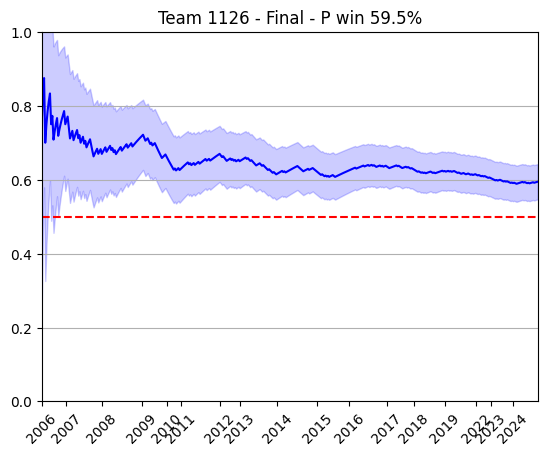

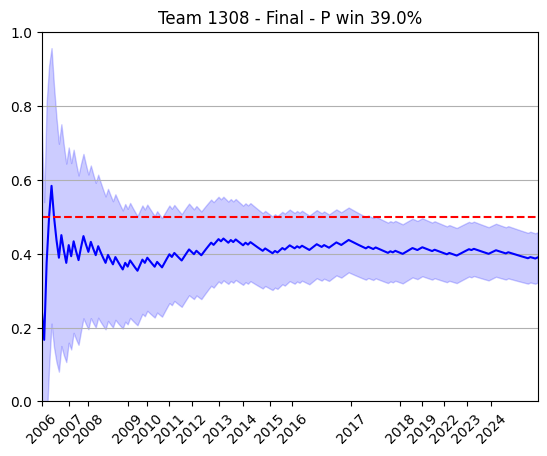

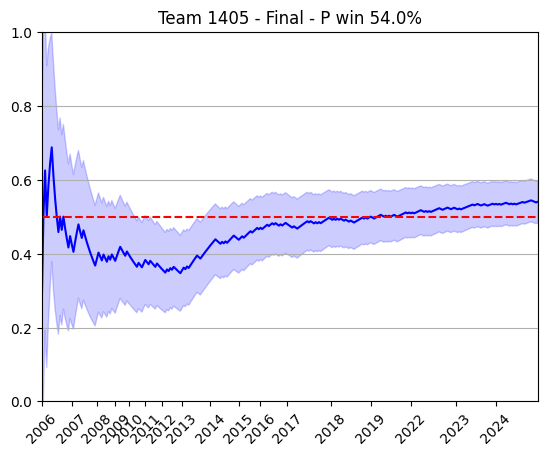

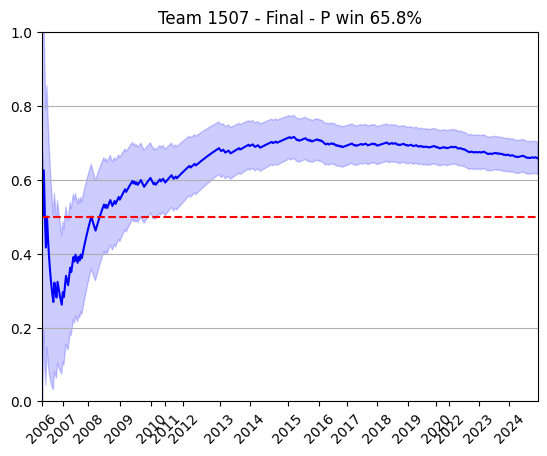

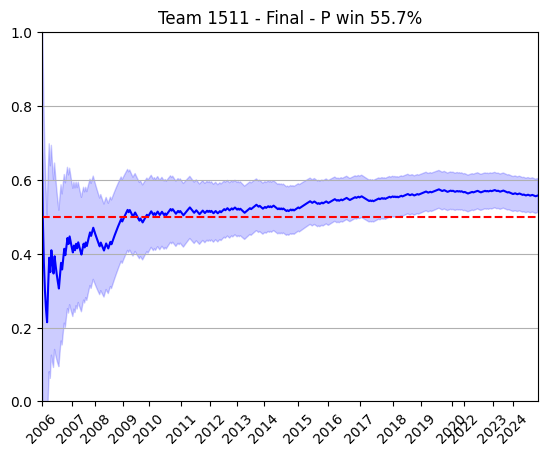

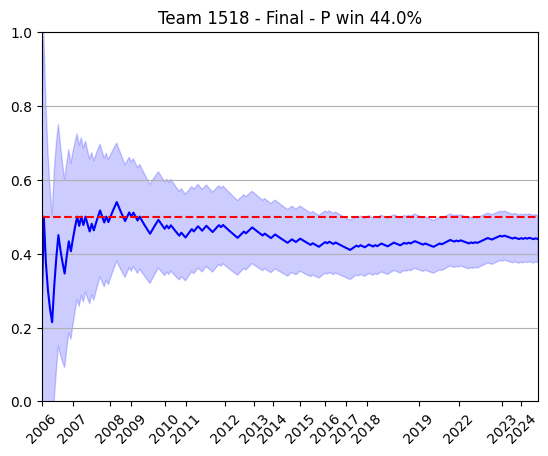

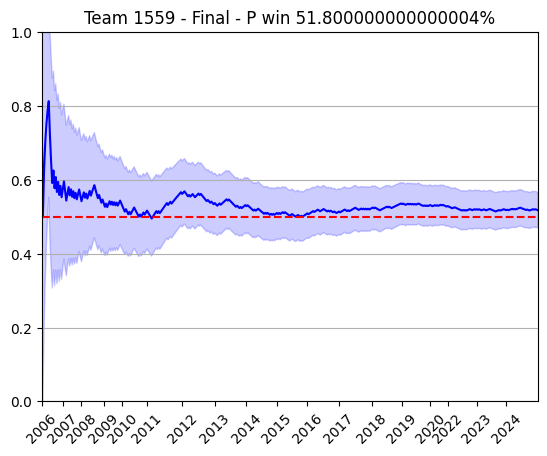

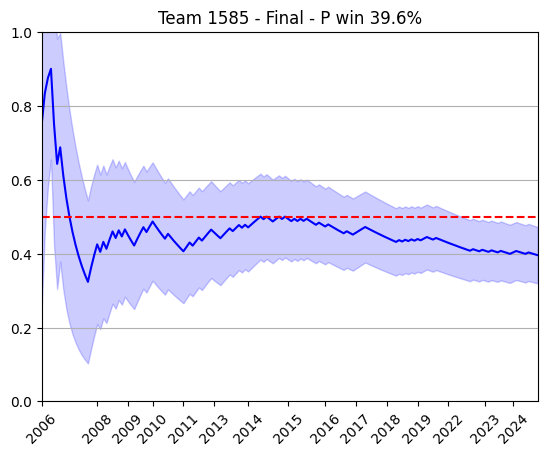

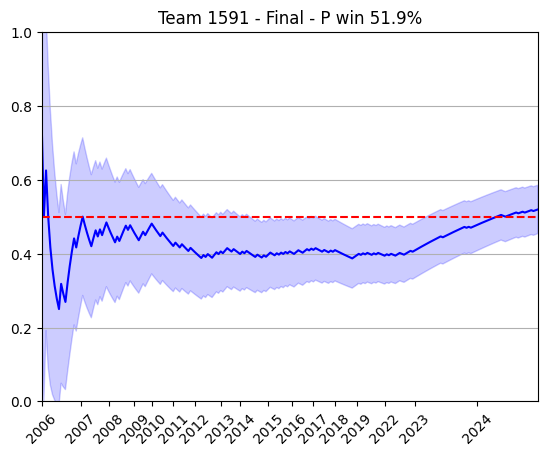

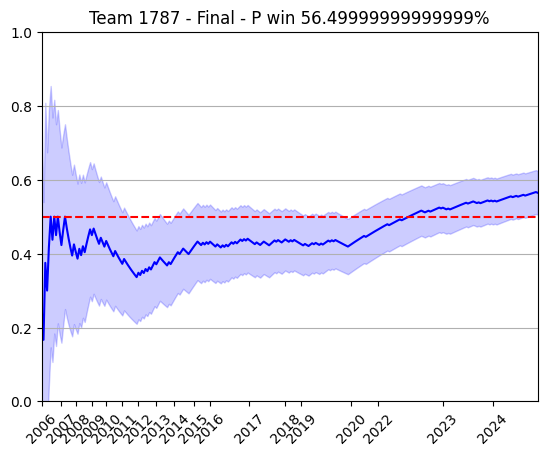

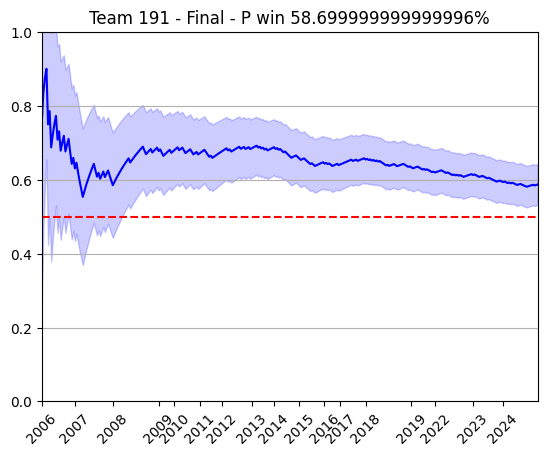

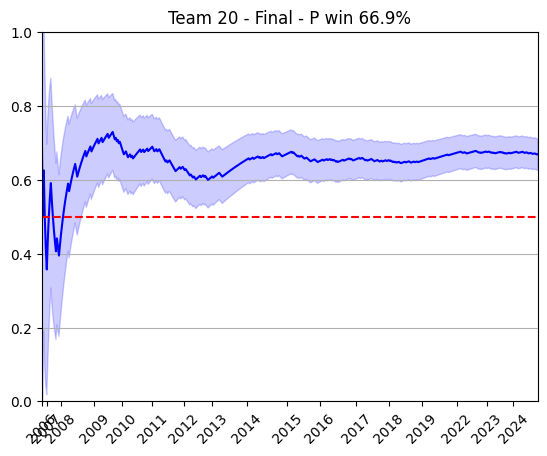

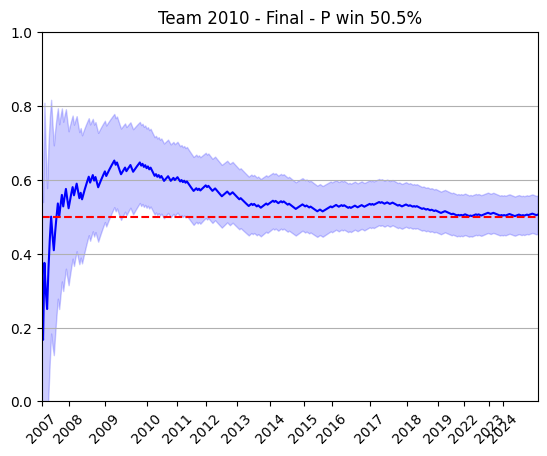

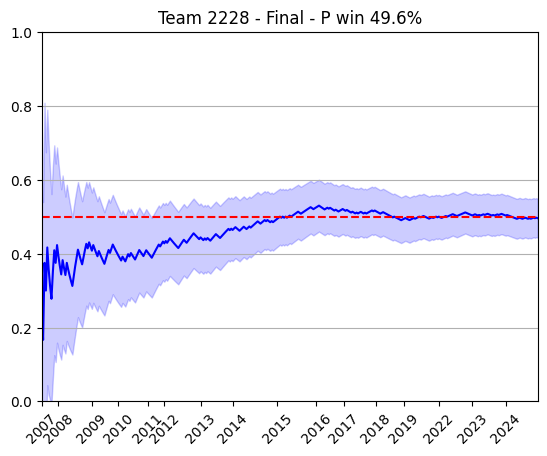

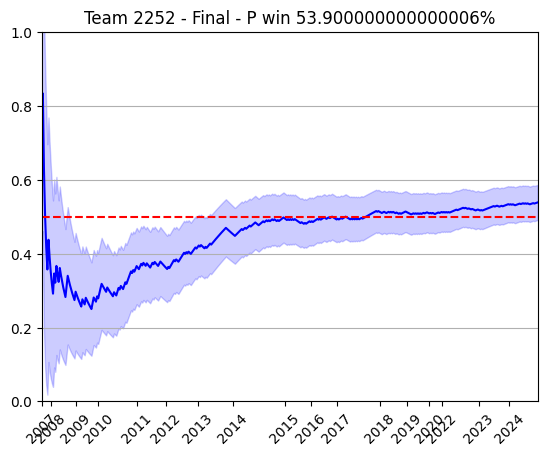

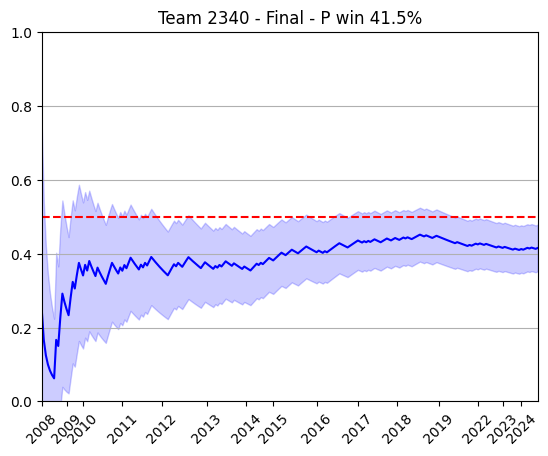

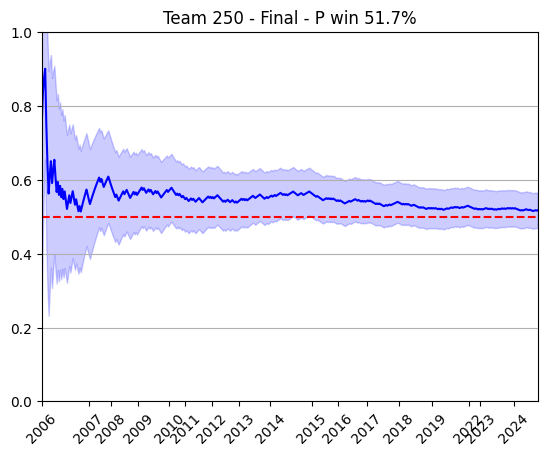

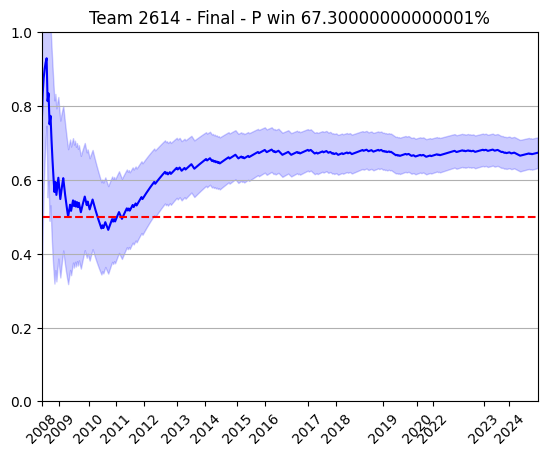

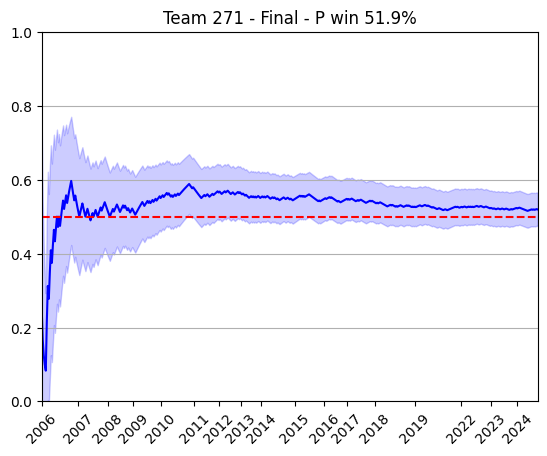

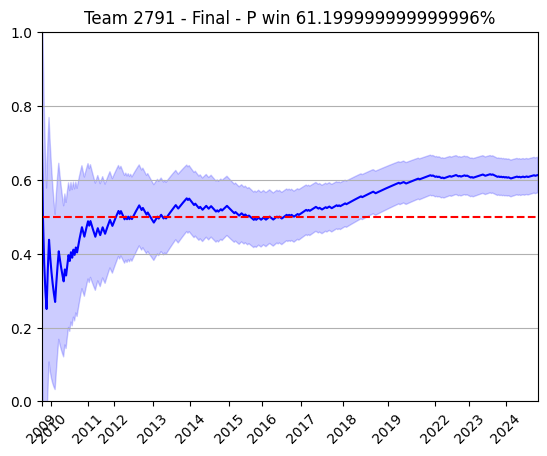

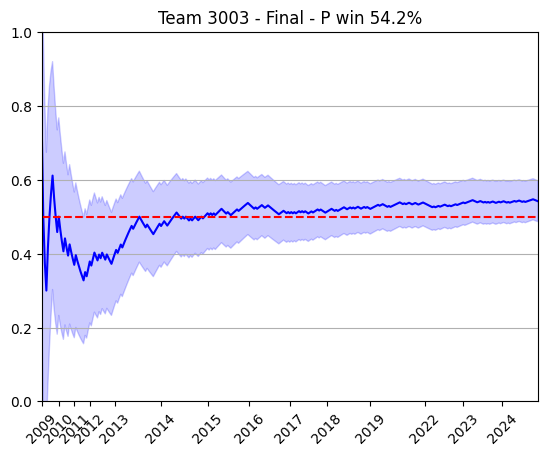

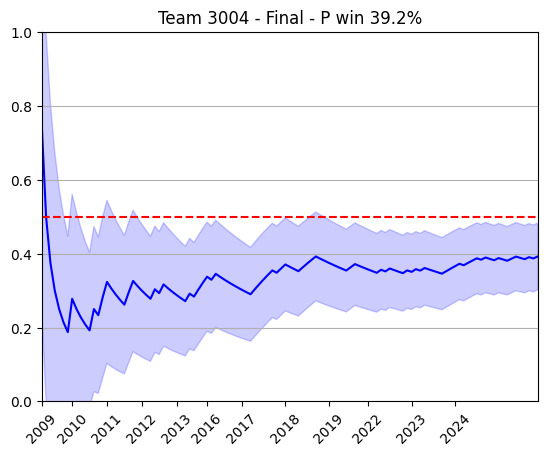

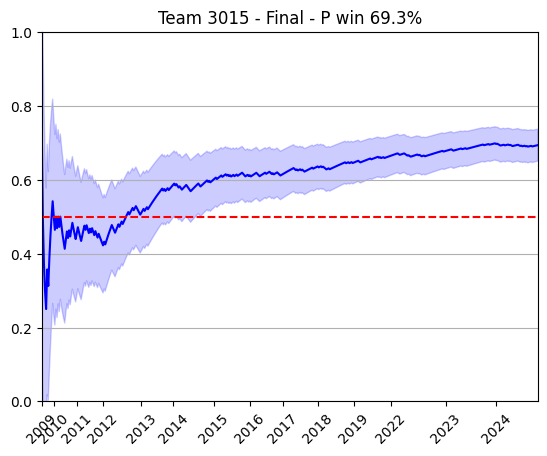

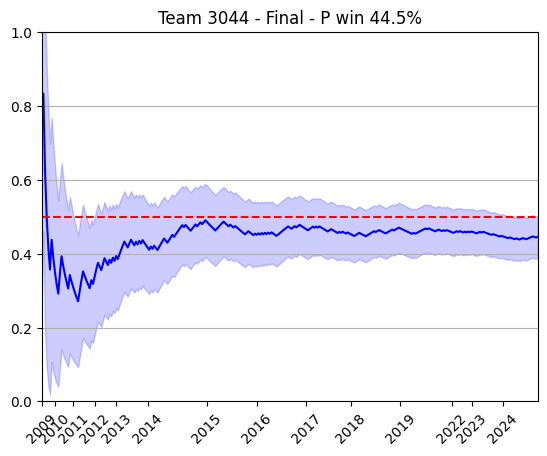

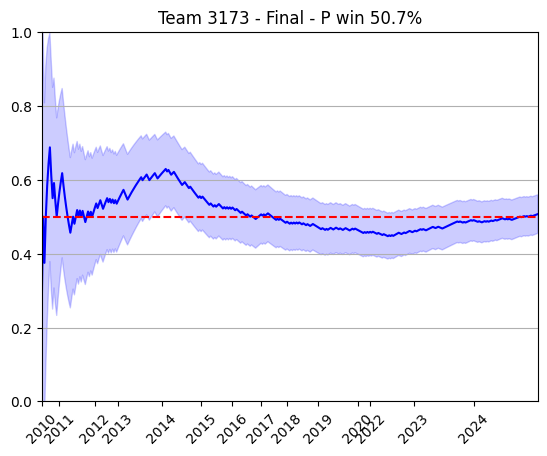

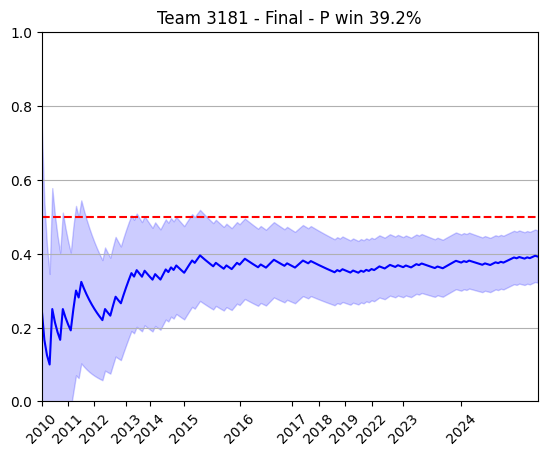

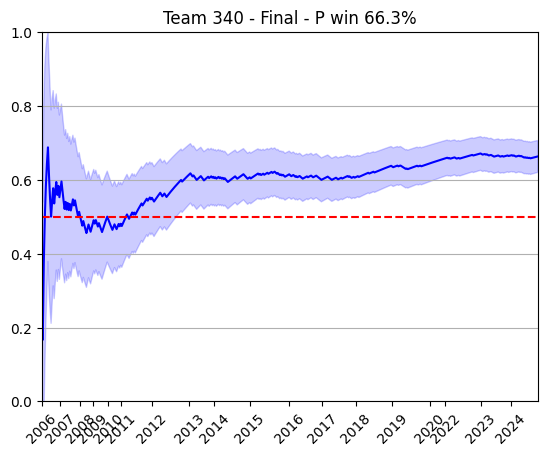

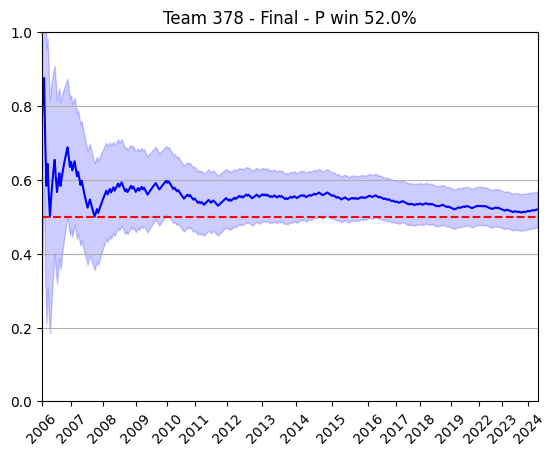

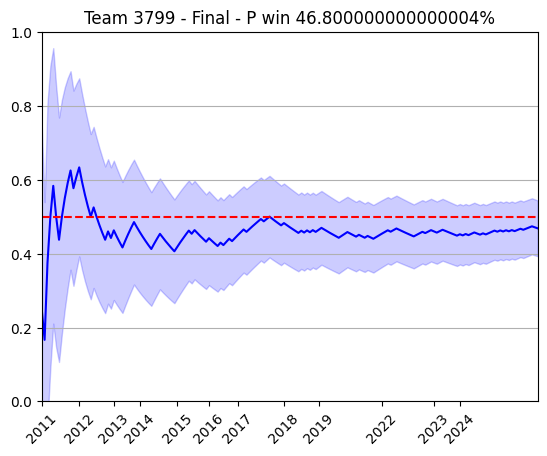

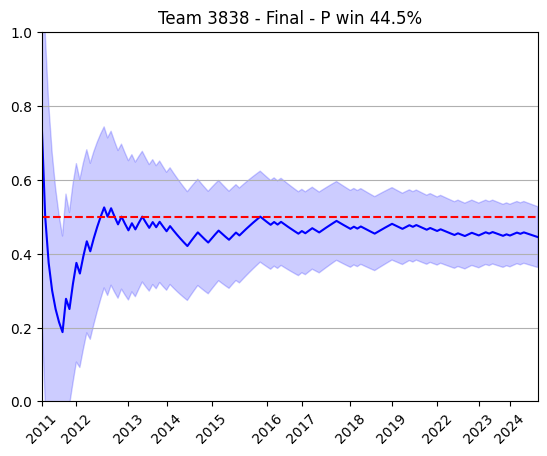

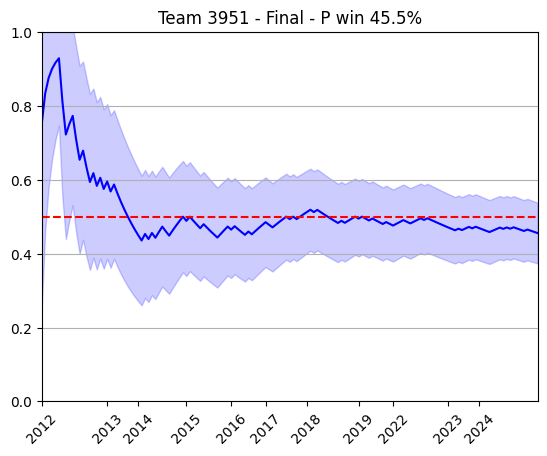

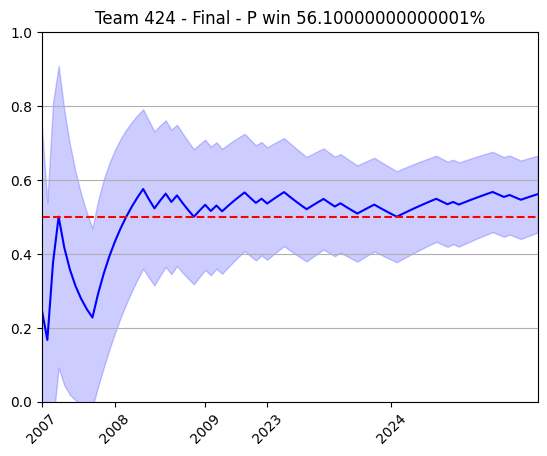

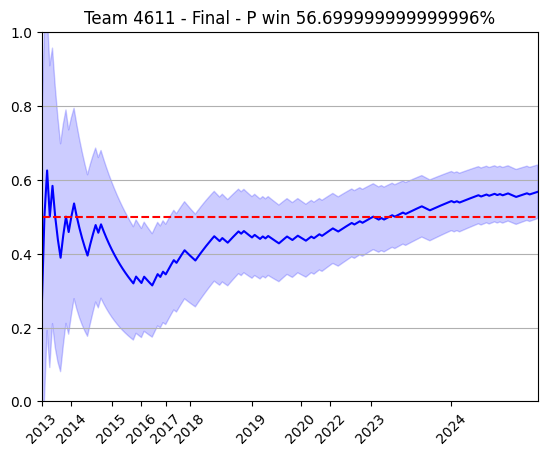

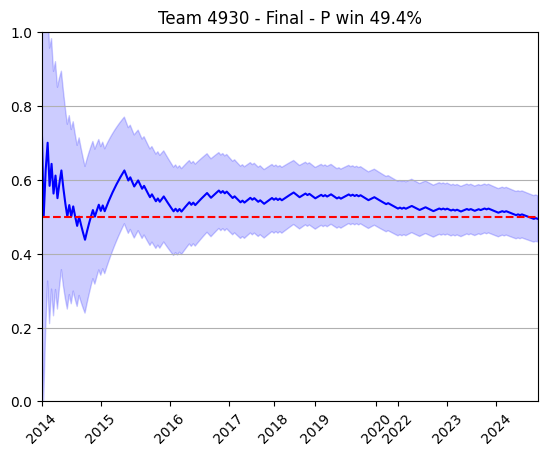

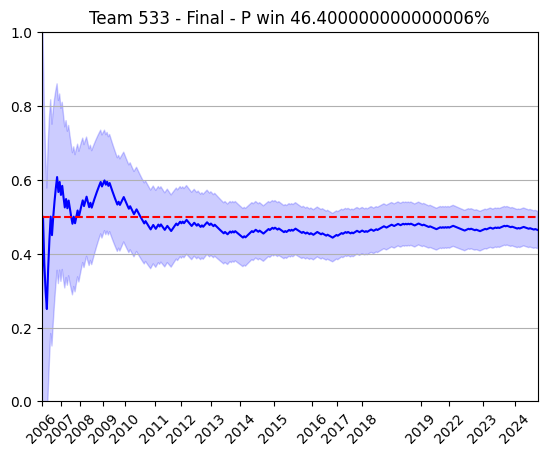

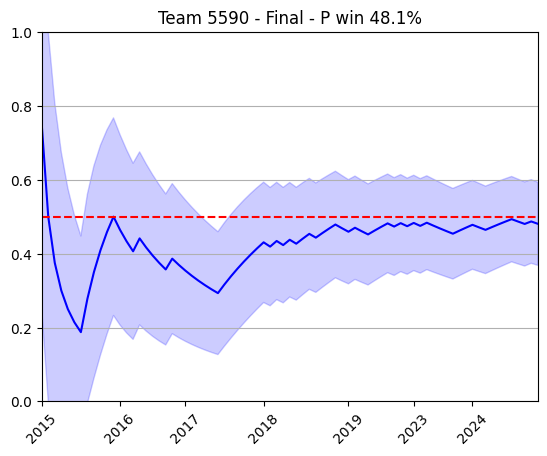

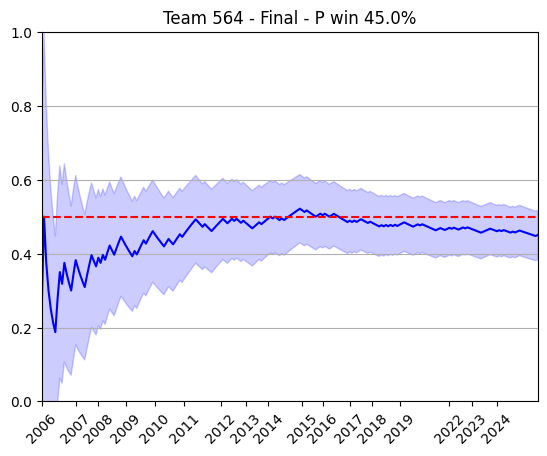

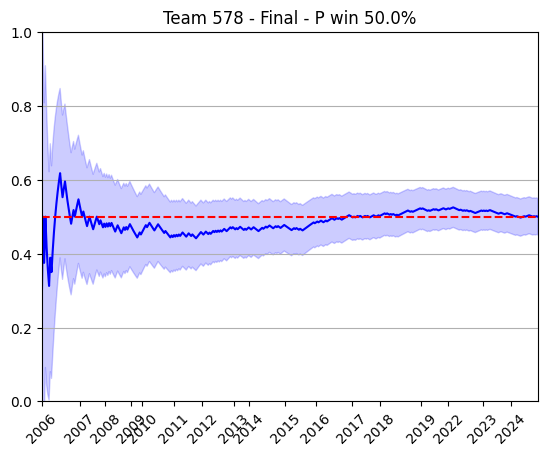

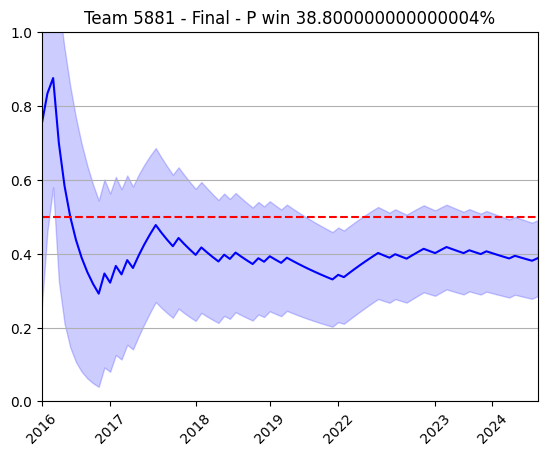

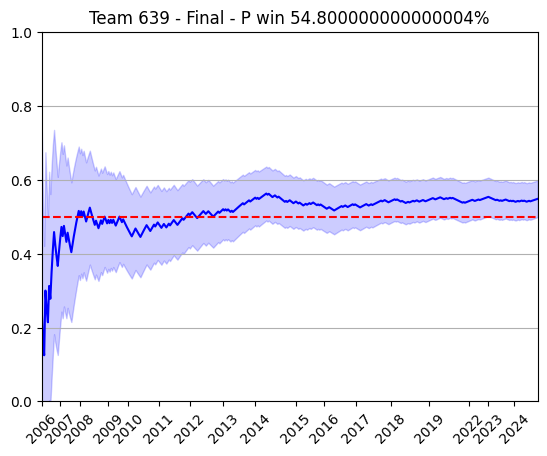

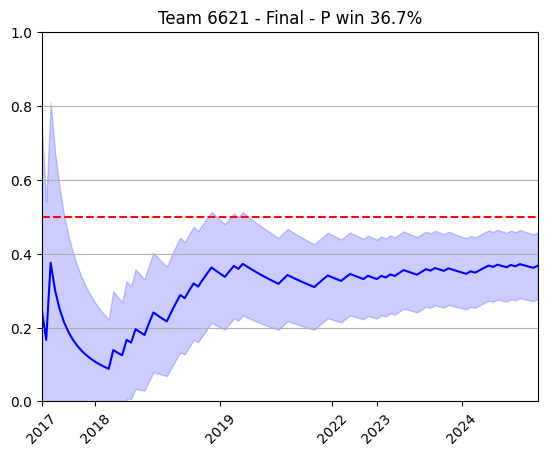

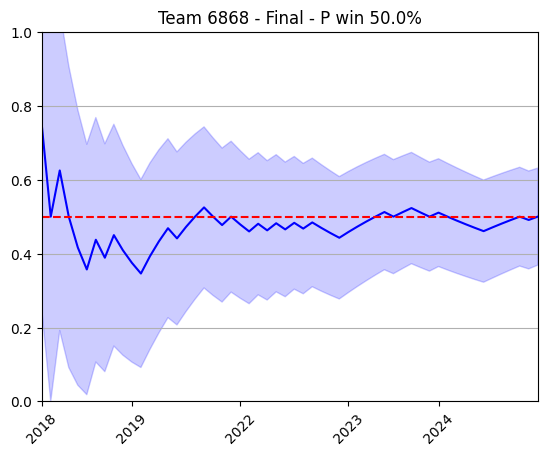

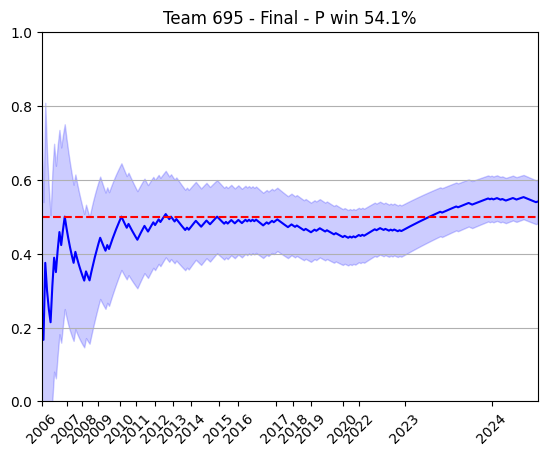

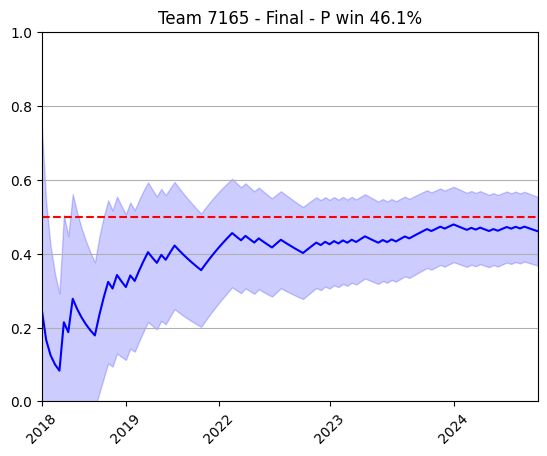

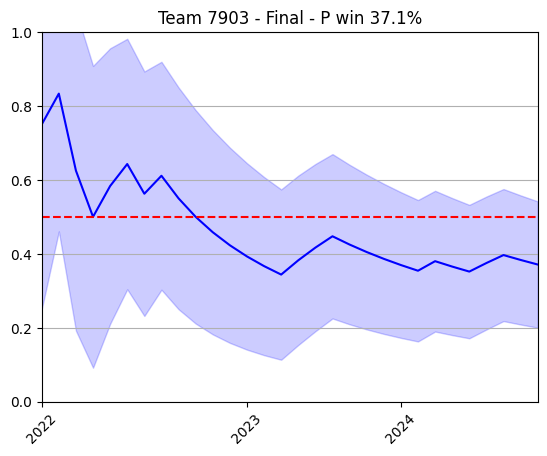

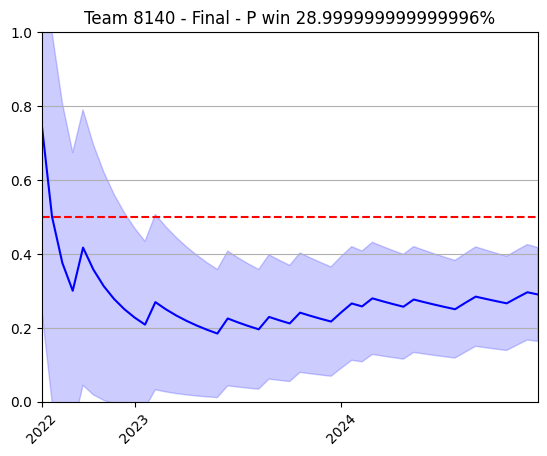

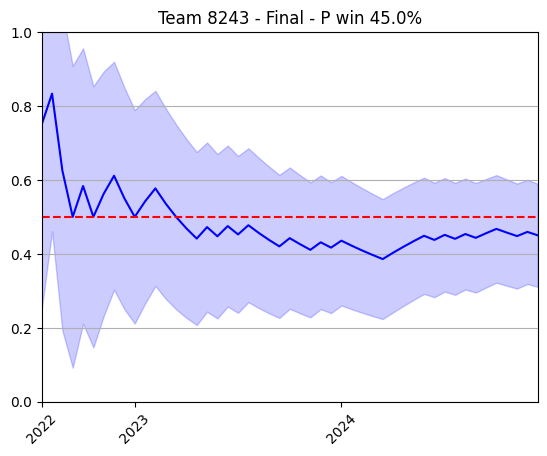

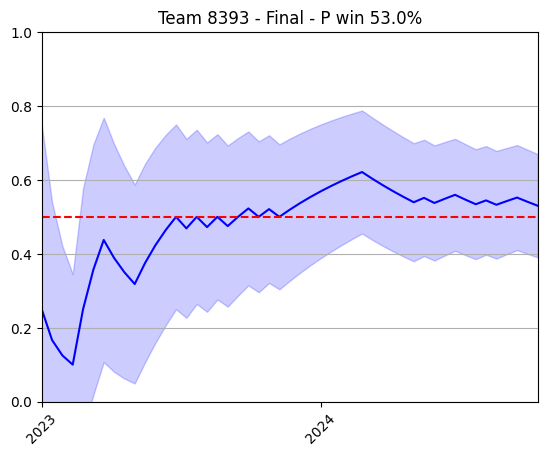

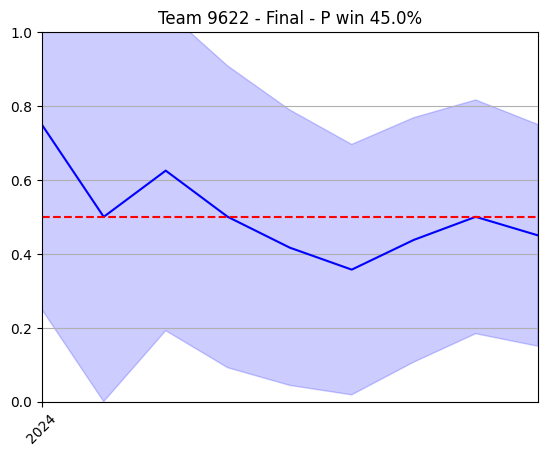

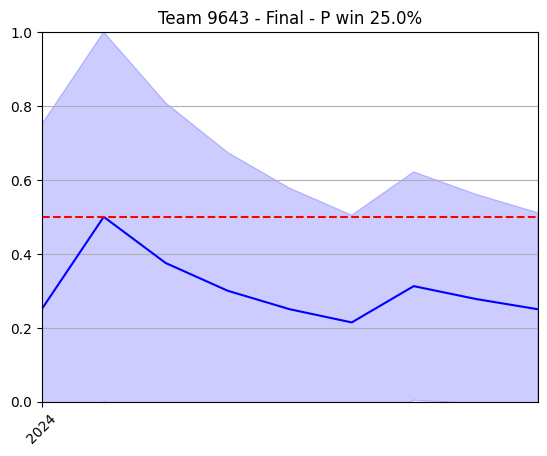

In [3]:
tba_teams("2025nyro")

def readEventJson():
    f = open("data/teams_2025nyro.json")
    data = json.load(f)
    f.close
    return(data)

teamNums = []
percents = []
data = readEventJson()
for team in data:
    teamNums.append(team["team_number"])
for num in teamNums:
    data = utils.get_win_loss_data(num)
    if data != {}:
        utils.get_viz(data, num, printGraph=False)
        mean_1, std_1, years_1 = utils.getGraphData(data)
        percents.append(utils.currentWinProb(mean_1))

[59.5, 39.0, 54.0, 65.8, 55.7, 44.0, 51.800000000000004, 39.6, 51.9, 56.49999999999999, 58.699999999999996, 66.9, 50.5, 49.6, 53.900000000000006, 41.5, 51.7, 67.30000000000001, 51.9, 61.199999999999996, 54.2, 39.2, 69.3, 44.5, 50.7, 39.2, 66.3, 52.0, 46.800000000000004, 44.5, 45.5, 56.10000000000001, 56.699999999999996, 49.4, 46.400000000000006, 48.1, 45.0, 50.0, 38.800000000000004, 54.800000000000004, 36.7, 50.0, 54.1, 46.1, 37.1, 28.999999999999996, 45.0, 53.0, 45.0, 25.0]


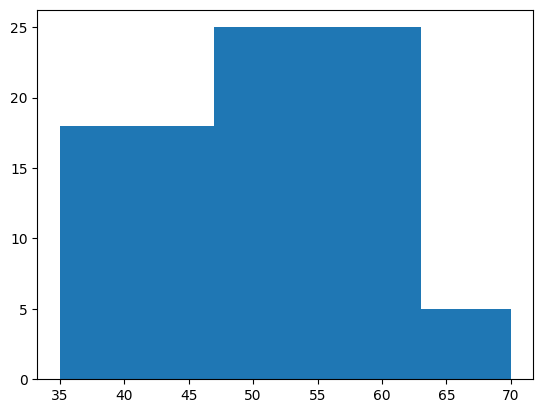

In [4]:
counts, bins = np.histogram(percents, bins=[35,47,63,70])
plt.hist(bins[:-1], bins, weights=counts)
print(percents)
plt.show()